# Stock Price Prediction using LSTM Neural Network and Tensorflow
## Clean Version with Compatible Libraries

What we need:
1. Load data
2. Scale data for machine learning model
3. Setup neural network
4. Compile model
5. Train neural network
6. Use the model for prediction
7. Draw the results chart

In [33]:
# Install compatible packages
!pip install -q yfinance pandas numpy scikit-learn tensorflow matplotlib
print("All packages installed successfully!")

All packages installed successfully!


In [34]:
import numpy as np
import pandas as pd
import datetime as dt
import time
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from collections import deque
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print("All imports successful!")

TensorFlow version: 2.20.0
All imports successful!


In [35]:
# SETTINGS
# Window size or the sequence length, 7 (1 week)
N_STEPS = 7

# Lookup steps, 1 is the next day, 3 = after tomorrow
LOOKUP_STEPS = [1, 2, 3]

# Stock ticker
STOCK = 'SOL-USD'

# Current date
date_now = dt.date.today().strftime('%Y-%m-%d')

# Calculate a date 1095 days back from today
date_past = (dt.date.today() - dt.timedelta(days=1095)).strftime('%Y-%m-%d')

print(f"Stock: {STOCK}")
print(f"Date range: {date_past} to {date_now}")
print(f"Current date: {date_now}")

Stock: SOL-USD
Date range: 2023-05-04 to 2026-05-03
Current date: 2026-05-03


In [36]:
# LOAD DATA from yfinance with retry logic
max_retries = 3
retry_count = 0
init_df = None

while retry_count < max_retries:
    try:
        print(f"Attempt {retry_count + 1} to download data...")
        init_df = yf.download(
            STOCK,
            start=date_past,
            end=date_now,
            progress=False
        )

        if init_df is not None and not init_df.empty:
            print("✓ Data loaded successfully!")
            break
    except Exception as e:
        retry_count += 1
        print(f"✗ Attempt {retry_count} failed: {str(e)[:100]}")
        if retry_count < max_retries:
            wait_time = 2 ** retry_count
            print(f"Retrying in {wait_time} seconds...")
            time.sleep(wait_time)
        else:
            print("Max retries exceeded.")
            raise

print(f"\nData shape: {init_df.shape}")
print(f"Data columns: {list(init_df.columns)}")

Attempt 1 to download data...
✓ Data loaded successfully!

Data shape: (1095, 5)
Data columns: [('Close', 'SOL-USD'), ('High', 'SOL-USD'), ('Low', 'SOL-USD'), ('Open', 'SOL-USD'), ('Volume', 'SOL-USD')]


/tmp/ipykernel_2844/3887526863.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  init_df = yf.download(


In [37]:
# Display first few rows
print("First few rows of downloaded data:")
print(init_df.head())

First few rows of downloaded data:
Price           Close       High        Low       Open     Volume
Ticker        SOL-USD    SOL-USD    SOL-USD    SOL-USD    SOL-USD
Date                                                             
2023-05-04  21.730349  22.441139  21.651815  22.218752  291826693
2023-05-05  22.826111  23.029722  21.706457  21.730816  423211212
2023-05-06  21.974262  23.222301  21.729971  22.828093  351934449
2023-05-07  21.844229  22.738605  21.808727  21.971926  303626005
2023-05-08  20.657463  21.807779  20.260630  21.807779  553548056


In [38]:
# Handle MultiIndex columns from yfinance
if isinstance(init_df.columns, pd.MultiIndex):
    # Flatten MultiIndex columns
    init_df.columns = ['_'.join(col).strip().lower() for col in init_df.columns.values]

# Normalize column names to lowercase
init_df.columns = [col.lower() for col in init_df.columns]

# yfinance returns 'close' or similar - find it
close_col = None
for col in init_df.columns:
    if 'close' in col and 'adj' not in col:
        close_col = col
        break

if close_col is None:
    # Fallback to any column with 'close'
    for col in init_df.columns:
        if 'close' in col:
            close_col = col
            break

if close_col is None:
    raise ValueError(f"Could not find 'close' column. Available columns: {list(init_df.columns)}")

# Keep only 'close' column
init_df = init_df[[close_col]].copy()
init_df.columns = ['close']

# Add date column based on index
init_df['date'] = init_df.index
init_df = init_df.reset_index(drop=True)

print("Processed data shape:", init_df.shape)
print("\nFirst few rows:")
print(init_df.head())

Processed data shape: (1095, 2)

First few rows:
       close       date
0  21.730349 2023-05-04
1  22.826111 2023-05-05
2  21.974262 2023-05-06
3  21.844229 2023-05-07
4  20.657463 2023-05-08


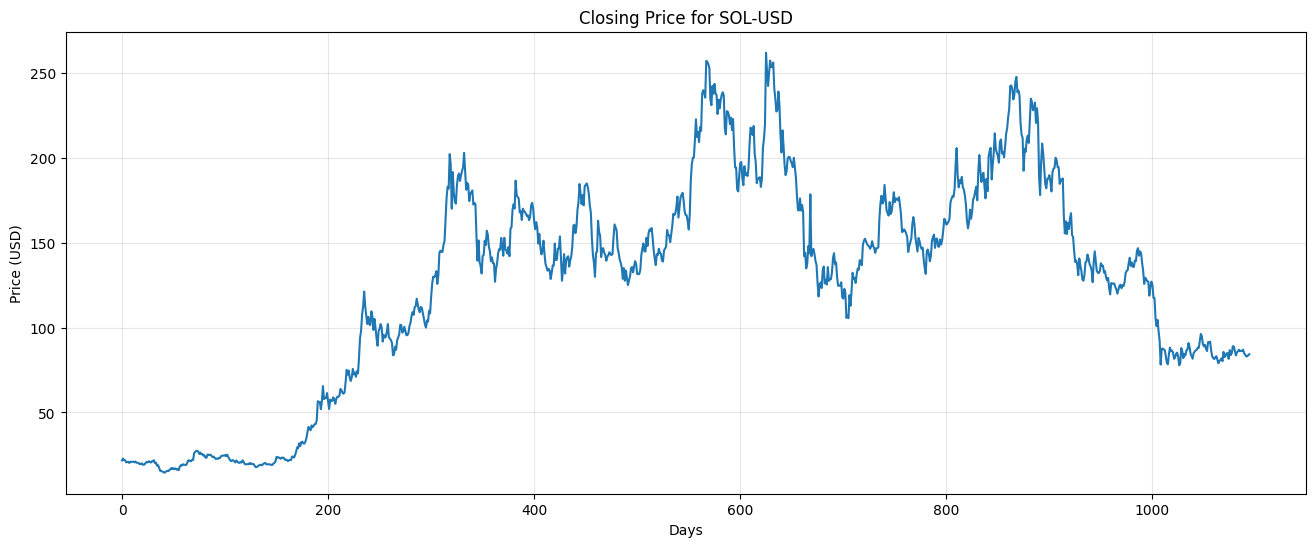

Min price: $14.49
Max price: $261.87
Mean price: $126.81


In [39]:
# Visualize closing price
plt.figure(figsize=(16, 6))
plt.plot(init_df['close'])
plt.title(f'Closing Price for {STOCK}')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Min price: ${init_df['close'].min():.2f}")
print(f"Max price: ${init_df['close'].max():.2f}")
print(f"Mean price: ${init_df['close'].mean():.2f}")

In [40]:
# Scale data - FIT ONLY ON TRAINING DATA to prevent data leakage
TRAIN_SPLIT = 0.8
split_idx = int(len(init_df) * TRAIN_SPLIT)

scaler = MinMaxScaler()

# Fit scaler on training portion ONLY
train_close = init_df['close'].values[:split_idx].reshape(-1, 1)
scaler.fit(train_close)

# Transform ALL data using the train-fitted scaler
init_df['scaled_close'] = scaler.transform(
    init_df['close'].values.reshape(-1, 1)
)

# PrepareData() call stays the same
df, last_sequence, X_all, Y_all = PrepareData(1)  # use 1-day for evaluation

# Split sequences using the same split_idx ratio
# (sequences are shorter than raw data due to windowing, so recalculate)
seq_split = int(len(X_all) * TRAIN_SPLIT)

X_train, X_test = X_all[:seq_split], X_all[seq_split:]
Y_train, Y_test = Y_all[:seq_split], Y_all[seq_split:]

def GetTrainedModel(x_train, y_train):
    model = Sequential([
        LSTM(60, return_sequences=True, input_shape=(N_STEPS, 1)),
        Dropout(0.3),
        LSTM(120, return_sequences=False),
        Dropout(0.3),
        Dense(20),
        Dense(1)
    ])
    model.compile(loss='mse', optimizer='adam')

    # Add EarlyStopping
    from tensorflow.keras.callbacks import EarlyStopping
    es = EarlyStopping(patience=10, restore_best_weights=True)

    model.fit(
        x_train, y_train,
        batch_size=20,
        epochs=50,
        validation_split=0.1,
        callbacks=[es],
        verbose=1
    )
    return model

eval_model = GetTrainedModel(X_train, Y_train)

import numpy as np

# Predict on test sequences
Y_pred_scaled = eval_model.predict(X_test, verbose=0)

# Inverse transform both back to USD
Y_pred = scaler.inverse_transform(Y_pred_scaled)
Y_true = scaler.inverse_transform(Y_test.reshape(-1, 1))

# Compute metrics
mae  = np.mean(np.abs(Y_true - Y_pred))
rmse = np.sqrt(np.mean((Y_true - Y_pred) ** 2))
mape = np.mean(np.abs((Y_true - Y_pred) / Y_true)) * 100
r2   = 1 - np.sum((Y_true - Y_pred)**2) / np.sum((Y_true - np.mean(Y_true))**2)

print(f"\n{'='*45}")
print(f"  HOLDOUT TEST SET EVALUATION")
print(f"{'='*45}")
print(f"  MAE  : ${mae:.2f}")
print(f"  RMSE : ${rmse:.2f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2:.4f}")
print(f"{'='*45}")

# Automatic quality gate
if   mape < 5:  print("  Result: EXCELLENT — publishable ✓")
elif mape < 10: print("  Result: GOOD — publishable with caveats ✓")
elif mape < 20: print("  Result: ACCEPTABLE — needs improvement")
else:           print("  Result: POOR — revisit architecture")

print(f"Train sequences: {len(X_train)}")
print(f"Test sequences:  {len(X_test)}")

print(f"Scaler fitted on TRAINING data only ({split_idx} samples)")
print(f"  Scaler learned min: ${scaler.data_min_[0]:.2f}")
print(f"  Scaler learned max: ${scaler.data_max_[0]:.2f}")
print(f"  Note: test values may exceed [0,1] range - this is expected.")
print("\nFirst few rows with scaled values:")
print(init_df.head())

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - loss: 0.0303 - val_loss: 0.0091
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0047 - val_loss: 0.0026
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0043 - val_loss: 0.0026
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0038 - val_loss: 0.0029
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0038 - val_loss: 0.0024
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0033 - val_loss: 0.0023
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0031 - val_loss: 0.0037
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0034 - val_loss: 0.0049
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0031 - val_loss: 0.0022
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0030 - val_l

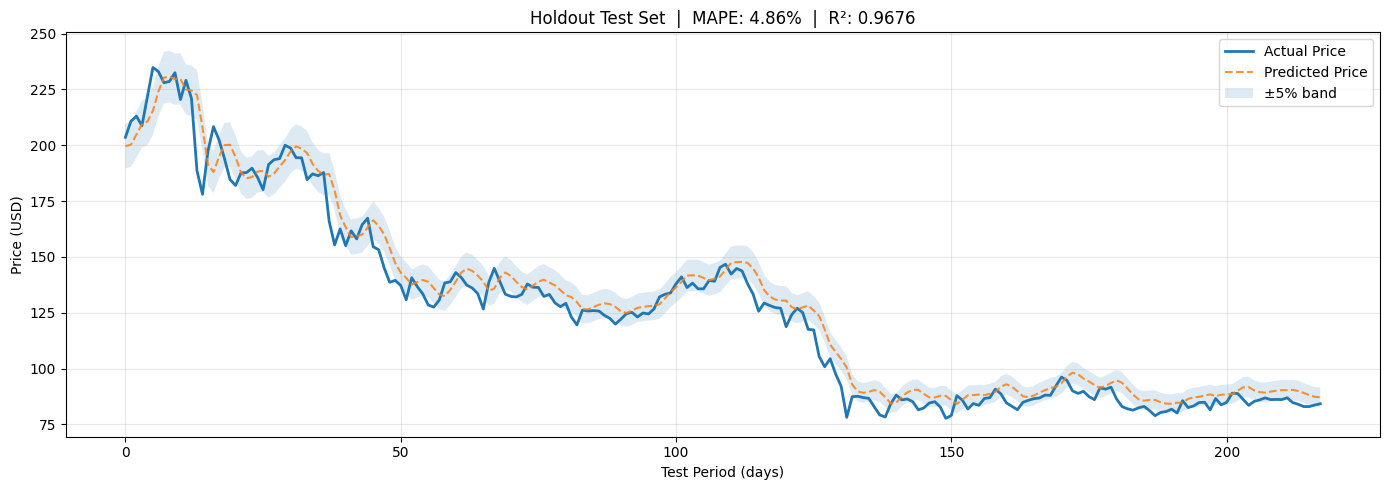

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(Y_true,  label='Actual Price',    linewidth=2)
plt.plot(Y_pred,  label='Predicted Price', linewidth=1.5, linestyle='--', alpha=0.85)
plt.fill_between(range(len(Y_true)),
                 Y_pred.flatten() * 0.95,
                 Y_pred.flatten() * 1.05,
                 alpha=0.15, label='±5% band')
plt.title(f'Holdout Test Set  |  MAPE: {mape:.2f}%  |  R²: {r2:.4f}')
plt.xlabel('Test Period (days)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# Prepare data for LSTM
def PrepareData(days):
    df = init_df.copy()
    df['future'] = df['scaled_close'].shift(-days)
    last_sequence = np.array(df[['scaled_close']].tail(days))
    df.dropna(inplace=True)
    sequence_data = []
    sequences = deque(maxlen=N_STEPS)

    for entry, target in zip(df[['scaled_close']].values, df['future'].values):
        sequences.append(entry)
        if len(sequences) == N_STEPS:
            sequence_data.append([np.array(sequences), target])

    last_sequence = list([s[:len(['scaled_close'])] for s in sequences]) + list(last_sequence)
    last_sequence = np.array(last_sequence).astype(np.float32)

    # Construct X and Y
    X, Y = [], []
    for seq, target in sequence_data:
        X.append(seq)
        Y.append(target)

    X = np.array(X)
    Y = np.array(Y)

    return df, last_sequence, X, Y

# Test prepare data
df_test, last_seq_test, X_test, Y_test = PrepareData(1)
print(f"Test shapes: X={X_test.shape}, Y={Y_test.shape}")

Test shapes: X=(1088, 7, 1), Y=(1088,)


In [43]:
# Build and train LSTM model
def GetTrainedModel(x_train, y_train):
    model = Sequential([
        LSTM(60, return_sequences=True, input_shape=(N_STEPS, 1)),
        Dropout(0.3),
        LSTM(120, return_sequences=False),
        Dropout(0.3),
        Dense(20),
        Dense(1)
    ])

    model.compile(loss='mse', optimizer='adam')

    # Train with validation split
    history = model.fit(
        x_train, y_train,
        batch_size=20,
        epochs=50,  # Reduced for faster training
        validation_split=0.1,
        verbose=1
    )

    return model, history

print("Model defined and ready for training!")

Model defined and ready for training!


In [27]:
# GET PREDICTIONS for next 3 days
print(f"\n{'='*60}")
print(f"Making predictions for {STOCK}")
print(f"{'='*60}")

predictions = []
models = []  # Store models for later use

for step in LOOKUP_STEPS:
    print(f"\n--- Predicting {step} day(s) ahead ---")

    df, last_sequence, x_train, y_train = PrepareData(step)
    x_train = x_train[:, :, :1].astype(np.float32)

    print(f"Training data shape: {x_train.shape}")

    # Train model
    model, history = GetTrainedModel(x_train, y_train)
    models.append(model)

    # Make prediction
    last_sequence = last_sequence[-N_STEPS:]
    last_sequence = np.expand_dims(last_sequence, axis=0)
    prediction = model.predict(last_sequence, verbose=0)
    predicted_price = scaler.inverse_transform(prediction)[0][0]

    predictions.append(round(float(predicted_price), 2))
    print(f"Predicted price: ${predicted_price:.2f}")

print(f"\n{'='*60}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025 - val_loss: 5.5033e-04
Epoch 38/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0023 - val_loss: 0.0017
Epoch 39/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 40/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025 - val_loss: 8.9530e-04
Epoch 41/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 42/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0023 - val_loss: 6.7409e-04
Epoch 43/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0022 - val_loss: 7.2057e-04
Epoch 44/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0022 - val_loss: 8.8407e-04
Epoch 45/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025 - val_loss: 5.4280e-04
Epoch 46/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0023 - val_loss: 8.4501e-04
Epoch 47/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0021 - val_loss: 6.8648e-04
Epoch 48/50
49/49 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Predicted price: $87.42

--- Predicting 3 day(s) ahead ---
Training data shape: (1086, 7, 1)
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0280 - val_loss: 0.0040
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0055 - val_loss: 0.0013
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0059 - val_loss: 8.6984e-04
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0053 - val_loss: 0.0016
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0050 - val_loss: 9.5886e-04
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0051 - val_loss: 0.0028
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0051 - val_loss: 0.0018
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0043 - val_loss: 0.0015
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0043 - val_loss: 0.0017
Epoch 10/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0046 - val_loss: 0.0016
Epoch 11/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/s

Predicted price: $87.66



In [28]:
# Display formatted predictions
if predictions and len(predictions) == len(LOOKUP_STEPS):
    print(f"\n{'='*60}")
    print(f"PREDICTIONS FOR {STOCK}")
    print(f"{'='*60}")

    for i, (step, price) in enumerate(zip(LOOKUP_STEPS, predictions), 1):
        future_date = dt.date.today() + dt.timedelta(days=step)
        print(f"Day {i} ({future_date}): ${price:.2f}")

    print(f"{'='*60}\n")


PREDICTIONS FOR SOL-USD
Day 1 (2026-05-04): $84.27
Day 2 (2026-05-05): $87.42
Day 3 (2026-05-06): $87.66



In [29]:
# Generate historical predictions (using last model)
print("Generating historical predictions...")
copy_df = init_df.copy()

# Use the last trained model to predict on full history
y_predicted = models[-1].predict(x_train, verbose=0)
y_predicted_transformed = np.squeeze(scaler.inverse_transform(y_predicted))

# Pad predictions to match DataFrame length
padding_size = len(copy_df) - len(y_predicted_transformed)
y_predicted_full = np.concatenate([np.full(padding_size, np.nan), y_predicted_transformed])

copy_df['predicted_close'] = y_predicted_full

print(f"Historical predictions generated!")
print(copy_df.tail(10))

Generating historical predictions...
Historical predictions generated!
          close       date  scaled_close  predicted_close
1085  86.141060 2026-04-23      0.289650        89.288330
1086  86.231880 2026-04-24      0.290017        89.314026
1087  86.151176 2026-04-25      0.289691        89.858955
1088  86.970383 2026-04-26      0.293002        90.125664
1089  84.817787 2026-04-27      0.284301        90.248428
1090  84.038979 2026-04-28      0.281153        90.218544
1091  83.026871 2026-04-29      0.277061        90.424774
1092  83.023758 2026-04-30      0.277049        89.855103
1093  83.723503 2026-05-01      0.279877        89.009254
1094  84.276611 2026-05-02      0.282113        88.042282


In [30]:
# Add future predictions to DataFrame
print("Adding future predictions...")
today = dt.date.today()

for i, (step, pred_price) in enumerate(zip(LOOKUP_STEPS, predictions), 1):
    future_date = today + dt.timedelta(days=step)
    new_row = pd.DataFrame({
        'close': [pred_price],
        'date': [future_date],
        'scaled_close': [np.nan],
        'predicted_close': [pred_price]
    })
    copy_df = pd.concat([copy_df, new_row], ignore_index=True)

print(f"Future predictions added!")
print(copy_df.tail(5))

Adding future predictions...
Future predictions added!
          close                 date  scaled_close  predicted_close
1093  83.723503  2026-05-01 00:00:00      0.279877        89.009254
1094  84.276611  2026-05-02 00:00:00      0.282113        88.042282
1095  84.270000           2026-05-04           NaN        84.270000
1096  87.420000           2026-05-05           NaN        87.420000
1097  87.660000           2026-05-06           NaN        87.660000


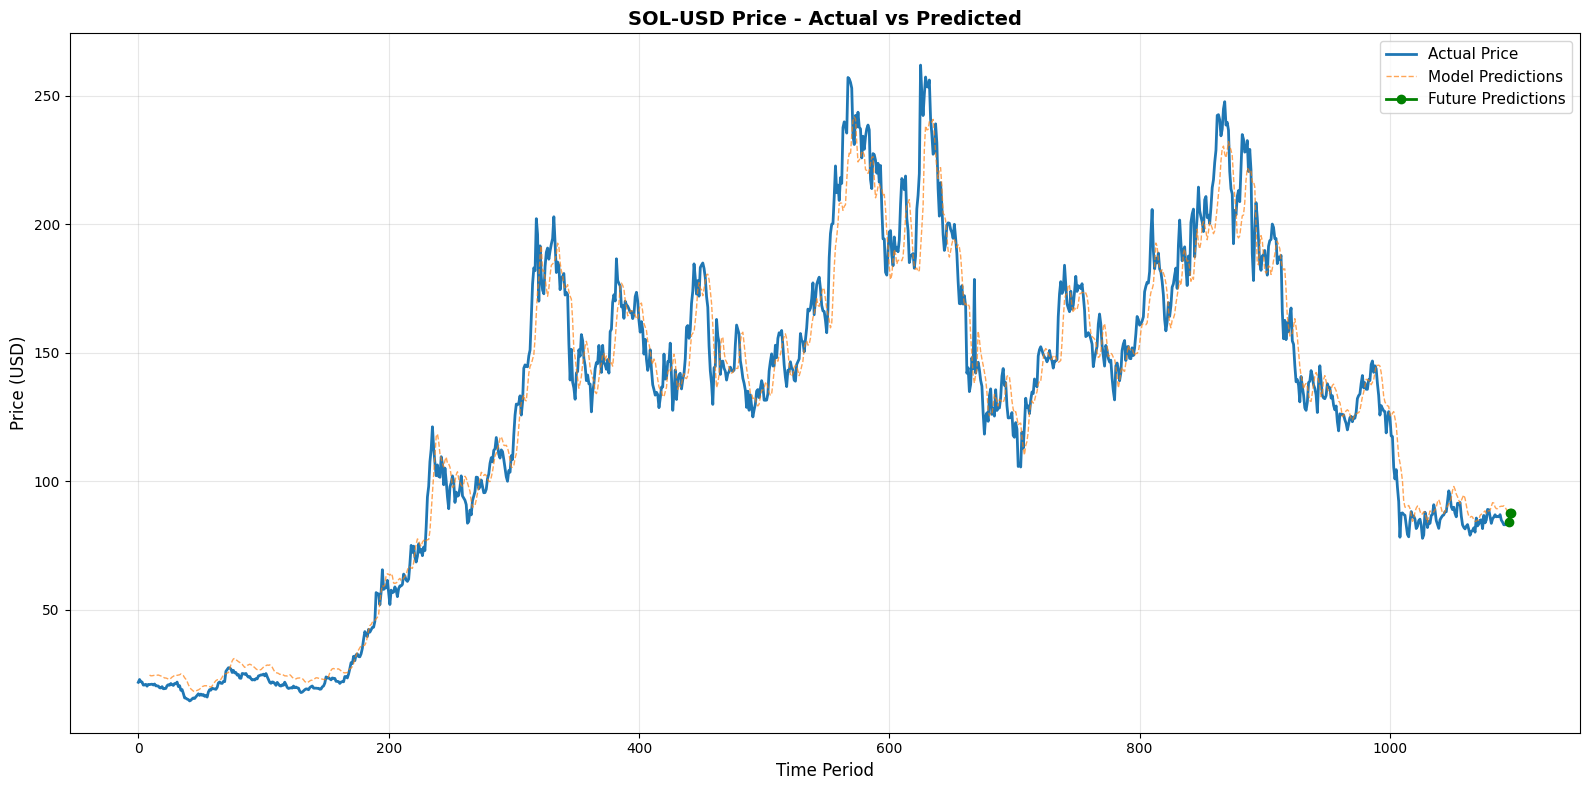

Chart displayed successfully!


In [31]:
# Plot results
plt.figure(figsize=(16, 8))

# Historical data
historical_data = copy_df[:-len(LOOKUP_STEPS)]
plt.plot(historical_data.index, historical_data['close'], label='Actual Price', linewidth=2)

# Historical predictions
valid_predictions = historical_data[historical_data['predicted_close'].notna()]
if len(valid_predictions) > 0:
    plt.plot(valid_predictions.index, valid_predictions['predicted_close'],
             label='Model Predictions', linewidth=1, linestyle='--', alpha=0.7)

# Future predictions
future_data = copy_df[-len(LOOKUP_STEPS):]
future_indices = range(len(copy_df) - len(LOOKUP_STEPS), len(copy_df))
plt.plot(future_indices, future_data['close'],
         label='Future Predictions', linewidth=2, marker='o', color='green')

plt.title(f'{STOCK} Price - Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Time Period', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Chart displayed successfully!")

In [32]:
# Summary
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")
print(f"Stock: {STOCK}")
print(f"Data points: {len(init_df)}")
print(f"Price range: ${init_df['close'].min():.2f} - ${init_df['close'].max():.2f}")
print(f"Current price: ${init_df['close'].iloc[-1]:.2f}")
print(f"\nNext 3 days predictions:")
for i, (step, price) in enumerate(zip(LOOKUP_STEPS, predictions), 1):
    future_date = dt.date.today() + dt.timedelta(days=step)
    print(f"  Day {i} ({future_date}): ${price:.2f}")
print(f"{'='*60}")


SUMMARY
Stock: SOL-USD
Data points: 1095
Price range: $14.49 - $261.87
Current price: $84.28

Next 3 days predictions:
  Day 1 (2026-05-04): $84.27
  Day 2 (2026-05-05): $87.42
  Day 3 (2026-05-06): $87.66
